# Week 4 — Function 4: Bayesian Optimisation (4D)

In [7]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [8]:
# Cell 3: Load data and inspect
# Function 4: Warehouse product placement optimisation, 4D input, Maximise

X = np.load('../data/function_4/initial_inputs.npy')
Y = np.load('../data/function_4/initial_outputs.npy')

print(f'Input  shape : {X.shape}   (n_samples x n_dimensions)')
print(f'Output shape : {Y.shape}  (n_samples,)')
print()

# Sort descending by Y value
X_list = list(X)
Y_list = list(Y)
pairs = sorted(zip(Y_list, X_list), reverse=True)
Y_sorted = [p[0] for p in pairs]
X_sorted = [p[1] for p in pairs]

print('=' * 78)
print('  All observations (sorted descending by Y)')
print('=' * 78)
for i, (y_val, x_val) in enumerate(zip(Y_sorted, X_sorted)):
    marker = '  <-- best' if i == 0 else ''
    print(f'  [{i+1:2d}]  X = [{x_val[0]:.6f}, {x_val[1]:.6f}, {x_val[2]:.6f}, {x_val[3]:.6f}]   Y = {y_val:+.6e}{marker}')
print('=' * 78)

best_Y = Y_sorted[0]
best_X = np.array(X_sorted[0])
print(f'\n  Best Y*  = {best_Y:.6e}')
print(f'  Best X*  = [{best_X[0]:.8f}, {best_X[1]:.8f}, {best_X[2]:.8f}, {best_X[3]:.8f}]')

Input  shape : (30, 4)   (n_samples x n_dimensions)
Output shape : (30,)  (n_samples,)

  All observations (sorted descending by Y)
  [ 1]  X = [0.577766, 0.428772, 0.425826, 0.249007]   Y = -4.025542e+00  <-- best
  [ 2]  X = [0.326076, 0.472367, 0.453192, 0.105887]   Y = -6.702089e+00
  [ 3]  X = [0.282138, 0.505987, 0.530531, 0.096302]   Y = -7.966775e+00
  [ 4]  X = [0.124871, 0.129770, 0.384400, 0.287076]   Y = -1.006963e+01
  [ 5]  X = [0.170347, 0.756959, 0.276520, 0.531231]   Y = -1.156574e+01
  [ 6]  X = [0.250946, 0.033693, 0.145380, 0.494932]   Y = -1.169993e+01
  [ 7]  X = [0.247708, 0.060445, 0.042186, 0.441324]   Y = -1.268168e+01
  [ 8]  X = [0.626071, 0.586751, 0.438806, 0.778858]   Y = -1.274177e+01
  [ 9]  X = [0.216911, 0.166086, 0.241372, 0.770062]   Y = -1.275832e+01
  [10]  X = [0.738613, 0.482103, 0.709366, 0.503970]   Y = -1.312278e+01
  [11]  X = [0.732812, 0.145250, 0.476813, 0.133366]   Y = -1.352765e+01
  [12]  X = [0.037825, 0.664853, 0.161982, 0.253924]   

In [9]:
# Cell 4: Fit GP with log-transformed Y

# Log-transform to handle extreme scale differences across observations
Y_fit = np.log(np.abs(Y) + 1e-300)

# Fixed RBF kernel (course style — no ConstantKernel, no optimisation)
kernel = RBF(length_scale=0.1, length_scale_bounds='fixed')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-10)
gp.fit(X, Y_fit)

print('=' * 62)
print('  GP Fitting Results')
print('=' * 62)
print(f'  Kernel                   : {gp.kernel_}')
print(f'  Log-marginal-likelihood  : {gp.log_marginal_likelihood_value_:.4f}')
print()

# Sanity check: predict at best known point
pred_mean, pred_std = gp.predict(best_X.reshape(1, -1), return_std=True)
actual_log = np.log(np.abs(best_Y) + 1e-300)
print('  Sanity check at best known X*:')
print(f'    X*                     = [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}, {best_X[3]:.6f}]')
print(f'    GP predicted mean      = {pred_mean[0]:.4f}  (log-space)')
print(f'    Actual log(|Y*|)       = {actual_log:.4f}  (log-space)')
print(f'    GP predicted std       = {pred_std[0]:.8f}')
print('=' * 62)

  GP Fitting Results
  Kernel                   : RBF(length_scale=0.1)
  Log-marginal-likelihood  : -134.4553

  Sanity check at best known X*:
    X*                     = [0.577766, 0.428772, 0.425826, 0.249007]
    GP predicted mean      = 1.3927  (log-space)
    Actual log(|Y*|)       = 1.3927  (log-space)
    GP predicted std       = 0.00001000


In [10]:
# Cell 5: UCB acquisition over 10x10x10x10 grid

# Build 10x10x10x10 meshgrid over [0, 1]^4
x1 = np.linspace(0, 1, 10)
x2 = np.linspace(0, 1, 10)
x3 = np.linspace(0, 1, 10)
x4 = np.linspace(0, 1, 10)
grids = np.meshgrid(x1, x2, x3, x4)
X_grid = np.array(grids).reshape(4, -1).T  # shape (10000, 4)

# GP predictions across the full grid
post_mean, post_std = gp.predict(X_grid, return_std=True)

# UCB acquisition: mean + beta * std
beta = 2.5  #Higher beta = more exploration at early stage (Week 1, sparse data)
acquisition = post_mean + beta * post_std  # shape (10000,)

# Next query = grid point with highest UCB
best_idx = np.argmax(acquisition)
next_x   = X_grid[best_idx]
next_acq = acquisition[best_idx]

# Portal submission string
portal_string = f'{next_x[0]:.6f}-{next_x[1]:.6f}-{next_x[2]:.6f}-{next_x[3]:.6f}'

print('=' * 62)
print('  UCB Acquisition  (beta = 2.5, 10x10x10x10 grid)')
print('=' * 62)
print(f'  Grid size            : {len(X_grid)} points (10x10x10x10)')
print(f'  Max UCB value        : {next_acq:.4f}')
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}, {next_x[3]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  UCB Acquisition  (beta = 2.5, 10x10x10x10 grid)
  Grid size            : 10000 points (10x10x10x10)
  Max UCB value        : 4.7004
  Next query point     : [0.888889, 0.555556, 0.777778, 0.777778]

  Portal submission string:
  >>> 0.888889-0.555556-0.777778-0.777778 <<<


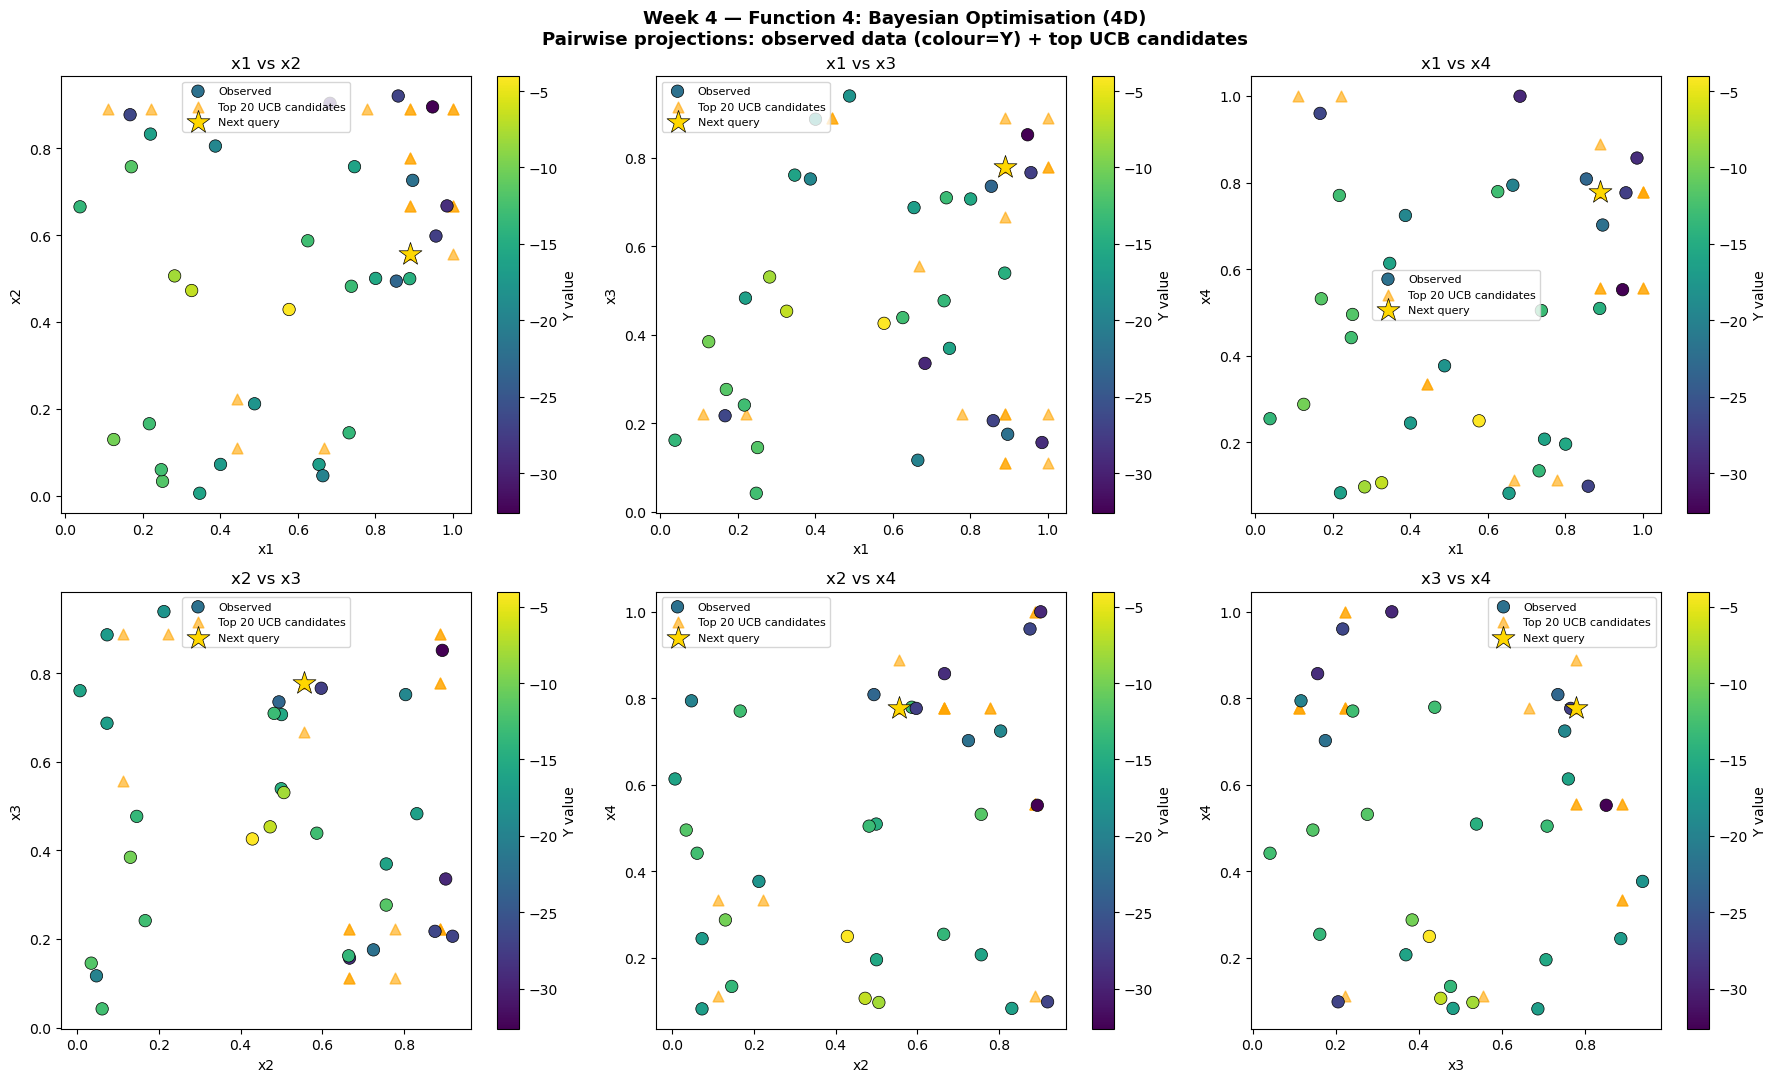

In [11]:
# Cell 6: Visualisation — pairwise scatter plots of observed data + top UCB candidates

# Top 20 candidates by UCB
top_idx = np.argsort(acquisition)[::-1][:20]
top_x   = X_grid[top_idx]

dim_labels = ['x1', 'x2', 'x3', 'x4']
pairs_to_plot = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.ravel()

for ax, (d_a, d_b) in zip(axes, pairs_to_plot):
    sc = ax.scatter(X[:, d_a], X[:, d_b], c=Y, cmap='viridis', s=80,
                    edgecolors='k', linewidths=0.5, zorder=5, label='Observed')
    plt.colorbar(sc, ax=ax, label='Y value')
    ax.scatter(top_x[:, d_a], top_x[:, d_b], c='orange', marker='^', s=60,
               alpha=0.6, zorder=4, label='Top 20 UCB candidates')
    ax.scatter(next_x[d_a], next_x[d_b], c='gold', marker='*', s=300, zorder=6,
               edgecolors='black', linewidths=0.5, label='Next query')
    ax.set_xlabel(dim_labels[d_a])
    ax.set_ylabel(dim_labels[d_b])
    ax.set_title(f'{dim_labels[d_a]} vs {dim_labels[d_b]}')
    ax.legend(fontsize=8)

plt.suptitle('Week 4 — Function 4: Bayesian Optimisation (4D)\nPairwise projections: observed data (colour=Y) + top UCB candidates',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Cell 7: Summary

print('=' * 62)
print('  SUMMARY — Bayesian Optimisation Results')
print('=' * 62)
print(f'  Function             : 4D Warehouse Product Placement Optimisation')
print(f'  Objective            : Maximise')
print(f'  Kernel               : RBF(length_scale=0.1, fixed)')
print(f'  Acquisition function : UCB  (beta = 2.5)')
print(f'  Y transform          : log(|Y| + 1e-300)')
print(f'  Grid search          : 10x10x10x10 meshgrid (10,000 points)')
print()
print(f'  Current best X*      : [{best_X[0]:.6f}, {best_X[1]:.6f}, {best_X[2]:.6f}, {best_X[3]:.6f}]')
print(f'  Current best Y*      : {best_Y:.6e}')
print()
print(f'  Next query point     : [{next_x[0]:.6f}, {next_x[1]:.6f}, {next_x[2]:.6f}, {next_x[3]:.6f}]')
print()
print('  Portal submission string:')
print(f'  >>> {portal_string} <<<')
print('=' * 62)

  SUMMARY — Bayesian Optimisation Results
  Function             : 4D Warehouse Product Placement Optimisation
  Objective            : Maximise
  Kernel               : RBF(length_scale=0.1, fixed)
  Acquisition function : UCB  (beta = 2.5)
  Y transform          : log(|Y| + 1e-300)
  Grid search          : 10x10x10x10 meshgrid (10,000 points)

  Current best X*      : [0.577766, 0.428772, 0.425826, 0.249007]
  Current best Y*      : -4.025542e+00

  Next query point     : [0.888889, 0.555556, 0.777778, 0.777778]

  Portal submission string:
  >>> 0.888889-0.555556-0.777778-0.777778 <<<
